In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
# Cell 1: Import Necessary Libraries
import os
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
# Comment: Importing all necessary libraries for feature extraction, data handling, and visualization.


In [3]:
# Cell 2: Define PretrainedFeatureExtractor Class
class PretrainedFeatureExtractor:
    def __init__(self, model_name="resnet18", layer="avgpool", device="cpu"):
        """
        Initialize the PretrainedFeatureExtractor.
        :param model_name: Name of the pretrained model (e.g., "resnet18").
        :param layer: Layer from which to extract features.
        :param device: Device to run the model on ("cpu" or "cuda").
        """
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        self.model = self._load_pretrained_model(model_name)
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def _load_pretrained_model(self, model_name):
        """
        Load the specified pretrained model and set it to evaluation mode.
        """
        try:
            model = getattr(models, model_name)(weights="IMAGENET1K_V1")
        except AttributeError:
            raise ValueError(f"Invalid model name '{model_name}'. Ensure it is supported by torchvision.")
        model = model.to(self.device)
        model.eval()
        return model

    def extract_features(self, image_folder, batch_size=16):
        """
        Extract features from all images in a folder.
        :param image_folder: Path to the folder containing images.
        :param batch_size: Batch size for feature extraction.
        :return: NumPy array of extracted features.
        """
        dataset = ImageDataset(image_folder, self.transform)
        if len(dataset) == 0:
            raise ValueError(f"No valid images found in the folder: {image_folder}")

        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        features = []

        with torch.no_grad():
            for inputs in dataloader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs).cpu().numpy()
                features.append(outputs)

        return np.vstack(features)

# Comment: This class handles the loading of a pretrained model, image preprocessing, and feature extraction.


In [4]:
# Cell 3: Define ImageDataset Class
class ImageDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        """
        Custom Dataset for loading images from a folder.
        :param image_folder: Path to the folder containing images.
        :param transform: Transformations to apply to the images.
        """
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        self.image_paths = [path for path in glob(os.path.join(image_folder, "*")) if path.lower().endswith(valid_extensions)]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        try:
            image = Image.open(image_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image
        except Exception as e:
            raise ValueError(f"Error loading image {image_path}: {e}")

# Comment: This class handles image loading and preprocessing.


In [5]:
# Cell 4: Initialize the Feature Extractor
feature_extractor = PretrainedFeatureExtractor(model_name="resnet18", device="cuda")

# Paths to the Image Folders
in_dist_folder = '/content/drive/MyDrive/in_dist_pool'
out_dist_folder = '/content/drive/MyDrive/out-dist-cxr'  # Optional OOD folder

# Comment: Setting up the feature extractor and defining paths for in-distribution (ID) and out-of-distribution (OOD) images.

# Cell 5: Extract and Save Features for In-Distribution Data
try:
    in_features = feature_extractor.extract_features(in_dist_folder)
    print(f"In-Distribution features shape: {in_features.shape}")
    in_features_path = "/content/drive/MyDrive/extracted_features/in_features.npy"
    os.makedirs(os.path.dirname(in_features_path), exist_ok=True)
    np.save(in_features_path, in_features)
    print(f"In-Distribution features saved to {in_features_path}")
except ValueError as e:
    print(e)

# Comment: Extracts features from ID images and saves them to a file.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


In-Distribution features shape: (1000, 1000)
In-Distribution features saved to /content/drive/MyDrive/extracted_features/in_features.npy


In [6]:
# Cell 6: Extract and Save Features for Out-of-Distribution Data
if os.path.exists(out_dist_folder):
    try:
        out_features = feature_extractor.extract_features(out_dist_folder)
        print(f"Out-of-Distribution features shape: {out_features.shape}")
        out_features_path = "/content/drive/MyDrive/extracted_features/out_features.npy"
        os.makedirs(os.path.dirname(out_features_path), exist_ok=True)
        np.save(out_features_path, out_features)
        print(f"Out-of-Distribution features saved to {out_features_path}")
    except ValueError as e:
        print(e)

# Comment: Checks if OOD folder exists, then extracts and saves OOD features.


Out-of-Distribution features shape: (896, 1000)
Out-of-Distribution features saved to /content/drive/MyDrive/extracted_features/out_features.npy


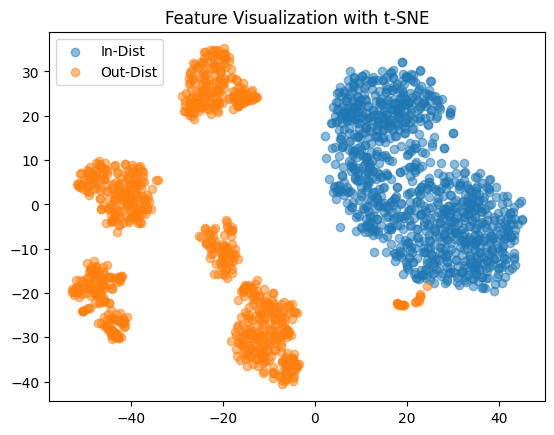

In [7]:
# Cell 7: Visualize Features with t-SNE
if 'in_features' in locals() and 'out_features' in locals():
    combined_features = np.vstack([in_features, out_features])
    labels = np.array([0] * len(in_features) + [1] * len(out_features))  # 0 for ID, 1 for OOD

    tsne = TSNE(n_components=2, random_state=42)
    reduced_features = tsne.fit_transform(combined_features)

    plt.scatter(reduced_features[labels == 0, 0], reduced_features[labels == 0, 1], alpha=0.5, label="In-Dist")
    plt.scatter(reduced_features[labels == 1, 0], reduced_features[labels == 1, 1], alpha=0.5, label="Out-Dist")
    plt.title("Feature Visualization with t-SNE")
    plt.legend()
    plt.show()
else:
    print("Not enough features for t-SNE visualization.")

# Comment: Combines ID and OOD features (if both exist) and visualizes them using t-SNE.


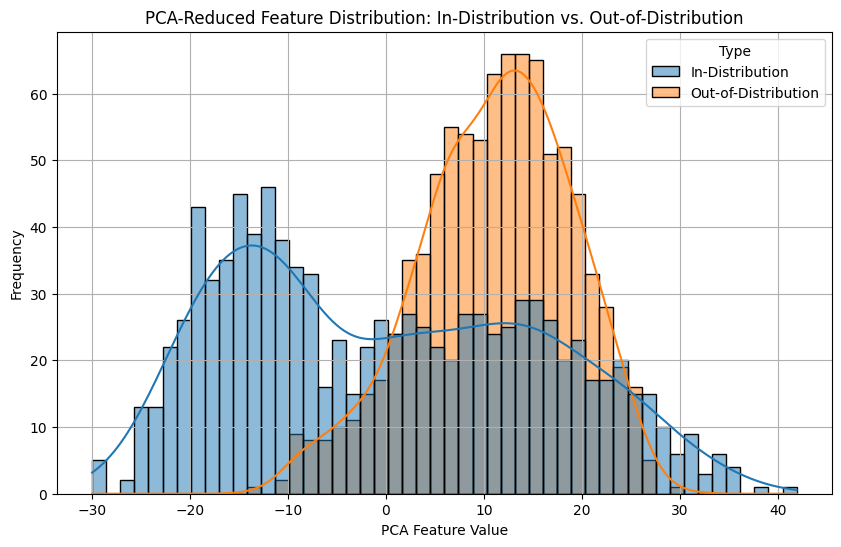

In [10]:
# Apply PCA to reduce the features to one dimension for distribution comparison
pca = PCA(n_components=1)
in_features_pca = pca.fit_transform(in_features)
out_features_pca = pca.transform(out_features)

# Combine the PCA-transformed features for plotting
in_features_pca_flattened = in_features_pca.flatten()
out_features_pca_flattened = out_features_pca.flatten()

# Create a DataFrame for visualization
import pandas as pd

df_pca = pd.DataFrame({
    'Feature Value': np.concatenate([in_features_pca_flattened, out_features_pca_flattened]),
    'Type': ['In-Distribution'] * len(in_features_pca_flattened) + ['Out-of-Distribution'] * len(out_features_pca_flattened)
})

# Plot the distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=df_pca, x='Feature Value', hue='Type', kde=True, bins=50, alpha=0.5)
plt.title('PCA-Reduced Feature Distribution: In-Distribution vs. Out-of-Distribution')
plt.xlabel('PCA Feature Value')
plt.ylabel('Frequency')
#plt.legend(title='Type')
plt.grid(True)
plt.show()
